In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  20-Node Small-World Grid — Network Analysis & Weak Link Detection       ║
# ║  Copy each section between the dividers into a separate Colab cell       ║
# ╚══════════════════════════════════════════════════════════════════════════╝


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — Install & Import
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "networkx", "matplotlib", "seaborn", "numpy", "--quiet"])

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# GPU check via CuPy (optional — used for matrix ops in Cell 5)
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print("GPU (CuPy) available — will use GPU for matrix operations")
except ImportError:
    GPU_AVAILABLE = False
    print("CuPy not found — using NumPy (CPU) for matrix operations")

print("All libraries loaded.")

CuPy not found — using NumPy (CPU) for matrix operations
All libraries loaded.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — Configuration  (edit here, then re-run all cells below)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── Network topology ──────────────────────────────────────────────────────
N_NODES    = 20           # Total nodes
GRAPH_TYPE = "watts_strogatz"  # "watts_strogatz" | "grid" | "random"

# Watts-Strogatz small-world parameters
WS_K = 4      # Nearest-neighbour ring connections per node
WS_P = 0.25   # Rewiring probability  (0 = ring lattice, 1 = fully random)

# Grid parameters  (used only when GRAPH_TYPE = "grid")
GRID_ROWS = 4
GRID_COLS = 5  # GRID_ROWS * GRID_COLS should equal N_NODES

# Erdos-Renyi parameters  (used only when GRAPH_TYPE = "random")
RANDOM_P = 0.20

RANDOM_SEED = 42  # reproducibility

# ── Edge weights ──────────────────────────────────────────────────────────
ADD_WEIGHTS  = True   # simulate link capacities as random edge weights
WEIGHT_LOW   = 1.0
WEIGHT_HIGH  = 10.0

# ── Visualisation ─────────────────────────────────────────────────────────
LAYOUT       = "spring"     # "spring" | "circular" | "spectral"
NODE_COLOR   = "#4A90D9"
EDGE_COLOR   = "#AAAAAA"
BRIDGE_COLOR = "#E74C3C"
NODE_SIZE    = 600
FIG_DPI      = 120

# ── Weak-link analysis ────────────────────────────────────────────────────
TOP_N_BETWEENNESS = 5   # show top-N critical edges

print("Configuration ready.")
print(f"  Graph type : {GRAPH_TYPE}")
print(f"  Nodes      : {N_NODES}")
print(f"  Seed       : {RANDOM_SEED}")

Configuration ready.
  Graph type : watts_strogatz
  Nodes      : 20
  Seed       : 42


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — Build the Network
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
np.random.seed(RANDOM_SEED)

if GRAPH_TYPE == "watts_strogatz":
    G = nx.watts_strogatz_graph(n=N_NODES, k=WS_K, p=WS_P, seed=RANDOM_SEED)
    topology_desc = f"Watts-Strogatz small-world (k={WS_K}, p={WS_P})"

elif GRAPH_TYPE == "grid":
    G = nx.grid_2d_graph(GRID_ROWS, GRID_COLS)
    mapping = {node: i for i, node in enumerate(G.nodes())}
    G = nx.relabel_nodes(G, mapping)
    topology_desc = f"2D grid ({GRID_ROWS}x{GRID_COLS})"

elif GRAPH_TYPE == "random":
    G = nx.erdos_renyi_graph(n=N_NODES, p=RANDOM_P, seed=RANDOM_SEED)
    topology_desc = f"Erdos-Renyi random (p={RANDOM_P})"

else:
    raise ValueError(f"Unknown GRAPH_TYPE: {GRAPH_TYPE}")

# Assign random edge weights (link capacity simulation)
if ADD_WEIGHTS:
    for u, v in G.edges():
        G[u][v]["weight"] = round(np.random.uniform(WEIGHT_LOW, WEIGHT_HIGH), 2)

# ── Basic network stats ───────────────────────────────────────────────────
degrees        = dict(G.degree())
avg_degree     = np.mean(list(degrees.values()))
is_connected   = nx.is_connected(G)

print(f"Graph built: {topology_desc}")
print(f"  Nodes            : {G.number_of_nodes()}")
print(f"  Edges            : {G.number_of_edges()}")
print(f"  Avg degree       : {avg_degree:.2f}")
print(f"  Connected graph  : {is_connected}")
if is_connected:
    print(f"  Avg path length  : {nx.average_shortest_path_length(G):.3f}")
    print(f"  Clustering coef  : {nx.average_clustering(G):.3f}")
    print(f"  Diameter         : {nx.diameter(G)}")

Graph built: Watts-Strogatz small-world (k=4, p=0.25)
  Nodes            : 20
  Edges            : 40
  Avg degree       : 4.00
  Connected graph  : True
  Avg path length  : 2.200
  Clustering coef  : 0.177
  Diameter         : 4


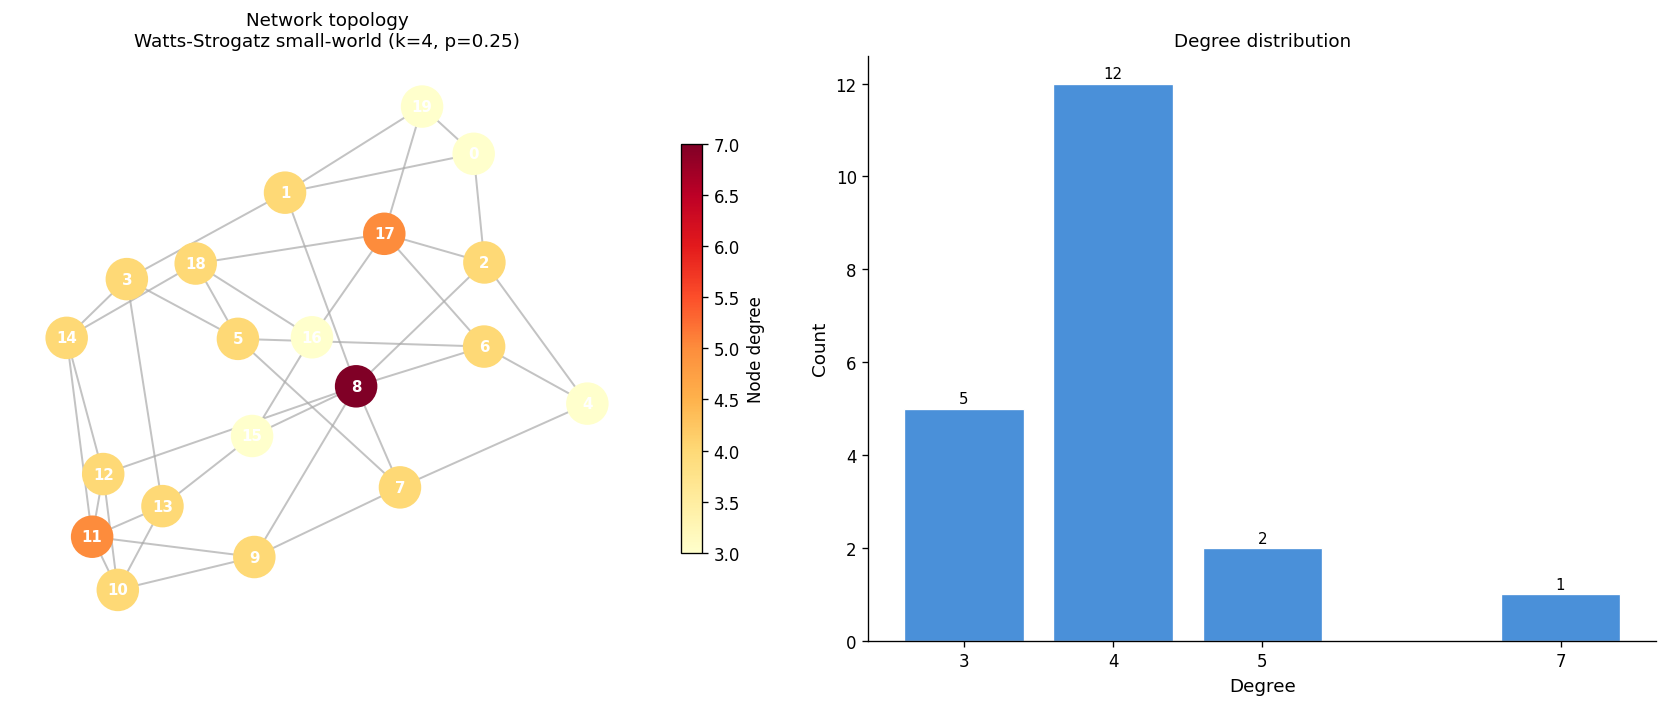

Cell 4 done. Node colour = degree (brighter = higher degree).


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — Visualise the Graph
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Compute layout once — reused in all subsequent cells
if LAYOUT == "spring":
    pos = nx.spring_layout(G, seed=RANDOM_SEED, k=1.5 / np.sqrt(N_NODES))
elif LAYOUT == "circular":
    pos = nx.circular_layout(G)
elif LAYOUT == "spectral":
    pos = nx.spectral_layout(G)
else:
    pos = nx.spring_layout(G, seed=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=FIG_DPI)

# Left: graph coloured by degree
ax = axes[0]
node_deg_vals = [degrees[n] for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_deg_vals,
                       cmap=plt.cm.YlOrRd, node_size=NODE_SIZE)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=EDGE_COLOR, width=1.2, alpha=0.7)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color="white", font_weight="bold")
sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,
     norm=plt.Normalize(vmin=min(node_deg_vals), vmax=max(node_deg_vals)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Node degree", shrink=0.7)
ax.set_title(f"Network topology\n{topology_desc}", fontsize=11)
ax.axis("off")

# Right: degree distribution
ax2 = axes[1]
unique_degs, counts = np.unique(list(degrees.values()), return_counts=True)
ax2.bar(unique_degs, counts, color=NODE_COLOR, edgecolor="white", linewidth=0.8)
ax2.set_xlabel("Degree", fontsize=11)
ax2.set_ylabel("Count",  fontsize=11)
ax2.set_title("Degree distribution", fontsize=11)
ax2.set_xticks(unique_degs)
for x, y in zip(unique_degs, counts):
    ax2.text(x, y + 0.05, str(y), ha="center", va="bottom", fontsize=9)
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig("graph_overview.png", bbox_inches="tight")
plt.show()
print("Cell 4 done. Node colour = degree (brighter = higher degree).")

Normalised Laplacian computed on CPU.


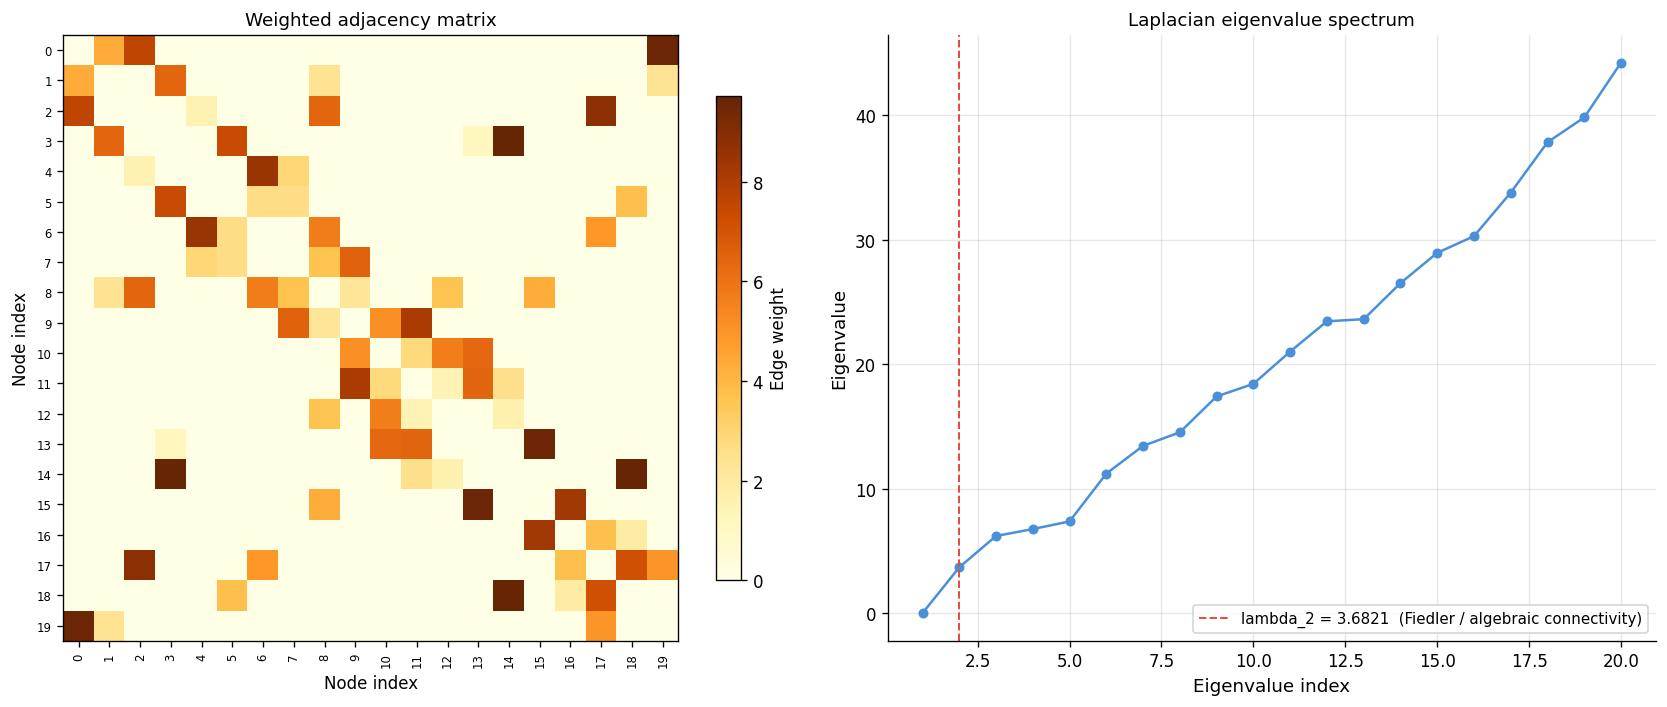


Matrix shape     : (20, 20)
Non-zero entries : 80  (40 undirected edges)
Fiedler value    : 3.6821  (higher = more robust connectivity)


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — Adjacency Matrix & Laplacian Spectrum
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Build adjacency matrix
weight_key = "weight" if ADD_WEIGHTS else None
A_np = nx.to_numpy_array(G, weight=weight_key)
matrix_label = "Weighted adjacency matrix" if ADD_WEIGHTS else "Unweighted adjacency matrix"

# Normalised Laplacian  D^{-1/2} A D^{-1/2}  — GPU if available
if GPU_AVAILABLE:
    A_gpu    = cp.asarray(A_np)
    deg_vec  = A_gpu.sum(axis=1)
    d_invsq  = cp.diag(1.0 / cp.sqrt(cp.where(deg_vec == 0, 1.0, deg_vec)))
    L_norm   = cp.asnumpy(cp.eye(N_NODES) - d_invsq @ A_gpu @ d_invsq)
    print("Normalised Laplacian computed on GPU.")
else:
    deg_vec = A_np.sum(axis=1)
    d_invsq = np.diag(1.0 / np.sqrt(np.where(deg_vec == 0, 1.0, deg_vec)))
    L_norm  = np.eye(N_NODES) - d_invsq @ A_np @ d_invsq
    print("Normalised Laplacian computed on CPU.")

# Fiedler value (lambda_2): algebraic connectivity
L_plain     = nx.laplacian_matrix(G).toarray().astype(float)
eigenvalues = np.sort(np.linalg.eigvalsh(L_plain))
fiedler_val = eigenvalues[1]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=FIG_DPI)

ax = axes[0]
cmap_name = "YlOrBr" if ADD_WEIGHTS else "Blues"
im = ax.imshow(A_np, cmap=cmap_name, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8,
             label="Edge weight" if ADD_WEIGHTS else "Connection (0/1)")
ax.set_title(matrix_label, fontsize=11)
ax.set_xlabel("Node index"); ax.set_ylabel("Node index")
ax.set_xticks(range(N_NODES)); ax.set_yticks(range(N_NODES))
ax.set_xticklabels(range(N_NODES), fontsize=7, rotation=90)
ax.set_yticklabels(range(N_NODES), fontsize=7)

ax2 = axes[1]
ax2.plot(range(1, len(eigenvalues) + 1), eigenvalues,
         "o-", color=NODE_COLOR, markersize=5, linewidth=1.5)
ax2.axvline(x=2, color=BRIDGE_COLOR, linestyle="--", linewidth=1.2,
            label=f"lambda_2 = {fiedler_val:.4f}  (Fiedler / algebraic connectivity)")
ax2.set_xlabel("Eigenvalue index", fontsize=11)
ax2.set_ylabel("Eigenvalue",       fontsize=11)
ax2.set_title("Laplacian eigenvalue spectrum", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig("adjacency_matrix.png", bbox_inches="tight")
plt.show()

print(f"\nMatrix shape     : {A_np.shape}")
print(f"Non-zero entries : {int(A_np.astype(bool).sum())}  ({int(A_np.astype(bool).sum()) // 2} undirected edges)")
print(f"Fiedler value    : {fiedler_val:.4f}  (higher = more robust connectivity)")


=== A) Bridge detection (Tarjan algorithm) ===
  No bridges found — graph is 2-edge-connected (robust against single edge removal).

=== B) Top-5 edges by betweenness centrality ===
  (fraction of all shortest paths that pass through each edge)
  #1  Edge  1 -- 8   centrality = 0.2316  weight = 2.4
  #2  Edge  8 -- 12  centrality = 0.1895  weight = 3.63
  #3  Edge  7 -- 8   centrality = 0.1842  weight = 3.62
  #4  Edge  5 -- 7   centrality = 0.1789  weight = 2.65
  #5  Edge  8 -- 9   centrality = 0.1474  weight = 2.26


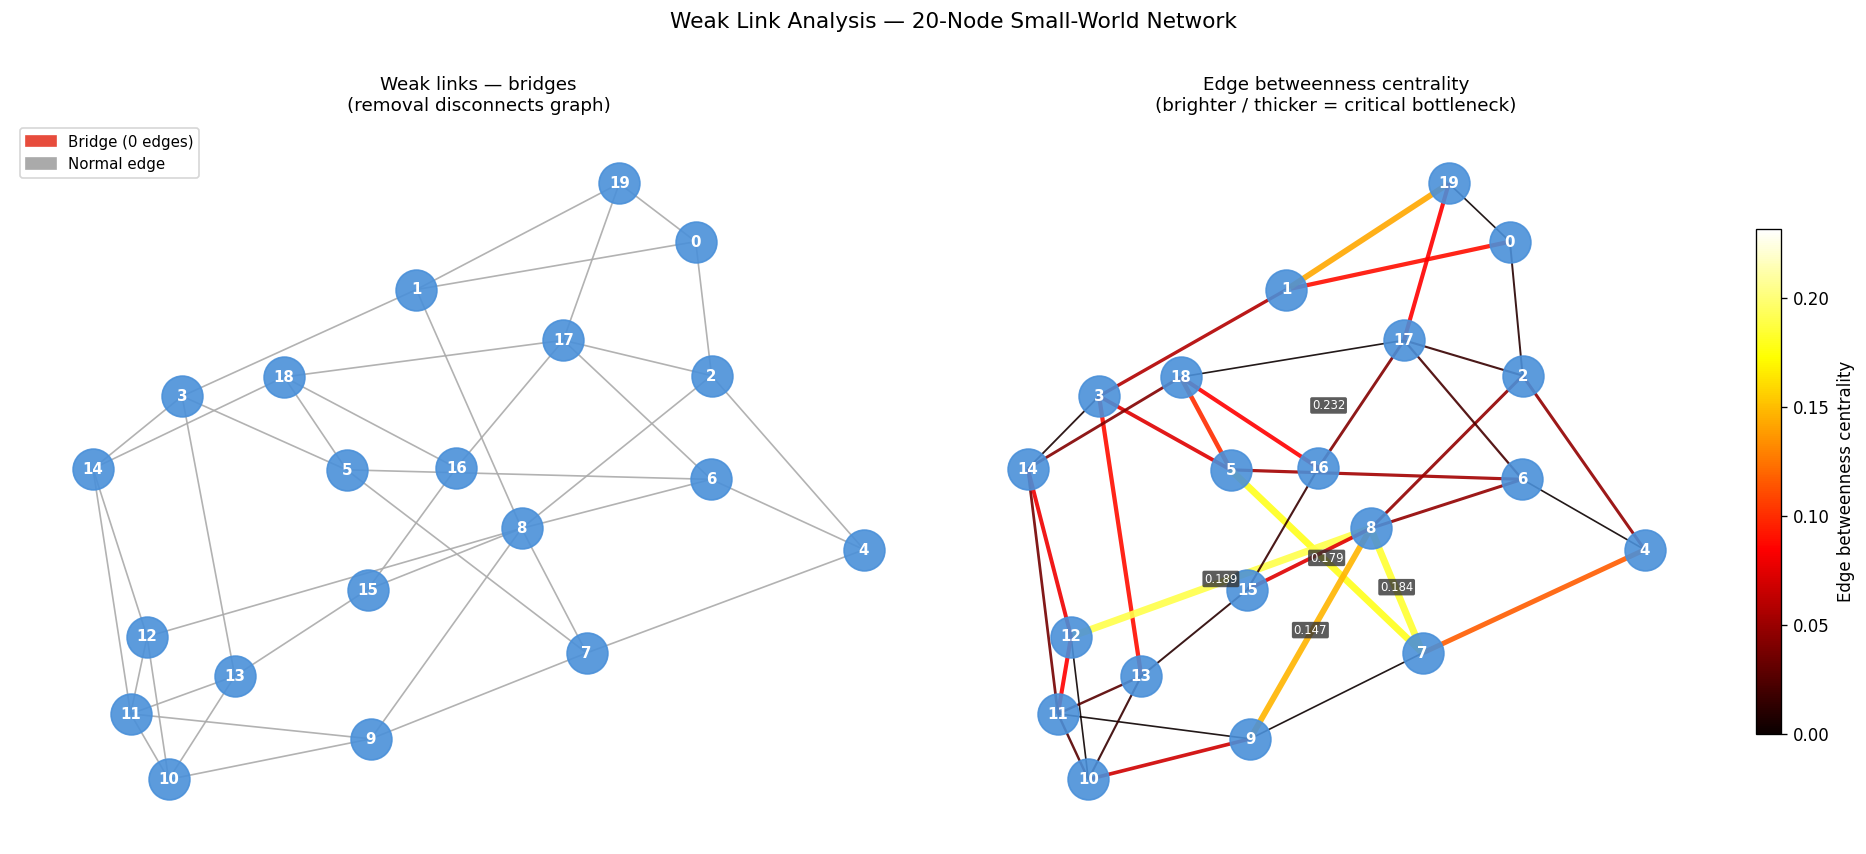


=== Network Robustness Summary ===
  Fiedler value (lambda_2)  : 3.6821  (algebraic connectivity; higher = more robust)
  Bridges found             : 0  (structural single points of failure)
  Max edge betweenness      : 0.2316  (traffic concentration)
  Most critical edge        : (1, 8)  (score = 0.2316)


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — Weak Link Detection
#   Method A: Graph bridges  (structural — removal disconnects graph)
#   Method B: Edge betweenness centrality  (traffic bottleneck)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── A: Bridges (Tarjan algorithm) ─────────────────────────────────────────
bridges    = list(nx.bridges(G))
bridge_set = {tuple(sorted(e)) for e in bridges}

print("=== A) Bridge detection (Tarjan algorithm) ===")
if bridges:
    print(f"  {len(bridges)} bridge(s) found — removing ANY of these disconnects the graph:")
    for b in bridges:
        w = G[b[0]][b[1]].get("weight", "n/a")
        print(f"    Edge  {b[0]:>2} -- {b[1]:<2}   weight = {w}")
else:
    print("  No bridges found — graph is 2-edge-connected (robust against single edge removal).")

# ── B: Edge betweenness centrality ────────────────────────────────────────
ebc        = nx.edge_betweenness_centrality(G, normalized=True,
                                             weight="weight" if ADD_WEIGHTS else None)
ebc_sorted = sorted(ebc.items(), key=lambda x: x[1], reverse=True)
top_edges  = ebc_sorted[:TOP_N_BETWEENNESS]

print(f"\n=== B) Top-{TOP_N_BETWEENNESS} edges by betweenness centrality ===")
print("  (fraction of all shortest paths that pass through each edge)")
for rank, (edge, score) in enumerate(top_edges, 1):
    w   = G[edge[0]][edge[1]].get("weight", "n/a")
    tag = "  <-- BRIDGE" if tuple(sorted(edge)) in bridge_set else ""
    print(f"  #{rank}  Edge {edge[0]:>2} -- {edge[1]:<2}  centrality = {score:.4f}  weight = {w}{tag}")

# ── Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=FIG_DPI)

def classify_edges(highlight_set, color_hi, color_lo, width_hi=3.5, width_lo=1.0):
    colors = []
    widths = []
    for e in G.edges():
        key = tuple(sorted(e))
        colors.append(color_hi if key in highlight_set else color_lo)
        widths.append(width_hi if key in highlight_set else width_lo)
    return colors, widths

# Left panel: bridges in red
ax = axes[0]
e_col, e_wid = classify_edges(bridge_set, BRIDGE_COLOR, EDGE_COLOR)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=NODE_COLOR, node_size=NODE_SIZE, alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=e_col, width=e_wid, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color="white", font_weight="bold")
legend_handles = [
    mpatches.Patch(color=BRIDGE_COLOR, label=f"Bridge ({len(bridges)} edge{'s' if len(bridges) != 1 else ''})"),
    mpatches.Patch(color=EDGE_COLOR,   label="Normal edge"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9)
ax.set_title("Weak links — bridges\n(removal disconnects graph)", fontsize=11)
ax.axis("off")

# Right panel: betweenness heat map
ax2 = axes[1]
ebc_vals  = np.array([ebc.get(e, ebc.get((e[1], e[0]), 0.0)) for e in G.edges()])
ebc_normd = ebc_vals / ebc_vals.max() if ebc_vals.max() > 0 else ebc_vals
e_cols2   = plt.cm.hot(ebc_normd)
e_wids2   = 1.0 + 4.0 * ebc_normd

nx.draw_networkx_nodes(G, pos, ax=ax2, node_color=NODE_COLOR, node_size=NODE_SIZE, alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax2, edge_color=e_cols2, width=e_wids2, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax2, font_size=9, font_color="white", font_weight="bold")

sm = plt.cm.ScalarMappable(cmap="hot", norm=plt.Normalize(vmin=0.0, vmax=float(ebc_vals.max())))
sm.set_array([])
plt.colorbar(sm, ax=ax2, label="Edge betweenness centrality", shrink=0.7)

# Annotate score on top-N edges
top_edge_set_local = {tuple(sorted(e)) for e, _ in top_edges}
for edge, score in top_edges:
    x = (pos[edge[0]][0] + pos[edge[1]][0]) / 2
    y = (pos[edge[0]][1] + pos[edge[1]][1]) / 2
    ax2.annotate(f"{score:.3f}", xy=(x, y), fontsize=7, ha="center", color="white",
                 bbox=dict(boxstyle="round,pad=0.15", fc="#333333", alpha=0.8, lw=0))

ax2.set_title("Edge betweenness centrality\n(brighter / thicker = critical bottleneck)", fontsize=11)
ax2.axis("off")

plt.suptitle("Weak Link Analysis — 20-Node Small-World Network", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("weak_links.png", bbox_inches="tight")
plt.show()

# ── Robustness summary ────────────────────────────────────────────────────
print("\n=== Network Robustness Summary ===")
print(f"  Fiedler value (lambda_2)  : {fiedler_val:.4f}  (algebraic connectivity; higher = more robust)")
print(f"  Bridges found             : {len(bridges)}  (structural single points of failure)")
print(f"  Max edge betweenness      : {float(ebc_vals.max()):.4f}  (traffic concentration)")
print(f"  Most critical edge        : {ebc_sorted[0][0]}  (score = {ebc_sorted[0][1]:.4f})")